# Model Training & Benchmarking
Replikasi paper: **"A Feature-Reduced SSH Brute-Force Detection Method Using XGBoost on AWS Infrastructure"**

Dataset: CSE-CIC-IDS2018 SSH-Bruteforce

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil di-import.")

Library berhasil di-import.


## 1. Data Ingestion & Cleaning

In [2]:
df = pd.read_csv('SSH-Bruteforce.csv')
print(f"Shape awal (raw): {df.shape}")
print(f"Jumlah NaN total: {df.isnull().sum().sum()}")
print(f"\nDistribusi label awal:")
print(df.iloc[:, -1].value_counts())

Shape awal (raw): (625919, 79)
Jumlah NaN total: 0

Distribusi label awal:
Label
Benign            438330
SSH-Bruteforce    187589
Name: count, dtype: int64


In [3]:
# Hapus baris dengan NaN
df.dropna(inplace=True)
print(f"Shape setelah drop NaN: {df.shape}")

# Hapus baris dengan Infinity
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_mask = np.isinf(df[numeric_cols]).any(axis=1)
print(f"Jumlah baris dengan Infinity: {inf_mask.sum()}")
df = df[~inf_mask]
print(f"Shape setelah drop Infinity: {df.shape}")

Shape setelah drop NaN: (625919, 79)
Jumlah baris dengan Infinity: 0
Shape setelah drop Infinity: (625919, 79)


## 2. Dataset Balancing & Label Encoding
Paper menggunakan dataset balanced (190k Benign + 190k Attack).
Kita undersample Benign agar distribusi seimbang.

In [4]:
label_col = [col for col in df.columns if 'label' in col.lower()][0]
print(f"Kolom target: {label_col}")
print(f"Distribusi sebelum balancing:\n{df[label_col].value_counts()}")

# Undersample Benign
attack_df = df[df[label_col] != 'Benign']
benign_df = df[df[label_col] == 'Benign']
n_attack = len(attack_df)

benign_undersampled = benign_df.sample(n=n_attack, random_state=42)
df_balanced = pd.concat([benign_undersampled, attack_df], axis=0).reset_index(drop=True)

print(f"\nShape setelah balancing: {df_balanced.shape}")
print(f"Distribusi setelah balancing:\n{df_balanced[label_col].value_counts()}")

Kolom target: Label
Distribusi sebelum balancing:
Label
Benign            438330
SSH-Bruteforce    187589
Name: count, dtype: int64

Shape setelah balancing: (375178, 79)
Distribusi setelah balancing:
Label
Benign            187589
SSH-Bruteforce    187589
Name: count, dtype: int64


In [5]:
# Encode label: Benign = 0, Attack = 1
df_balanced[label_col] = df_balanced[label_col].apply(
    lambda x: 0 if 'benign' in str(x).lower() else 1
)
print(f"Distribusi setelah encoding:\n{df_balanced[label_col].value_counts()}")

Distribusi setelah encoding:
Label
0    187589
1    187589
Name: count, dtype: int64


## 3. Data Splitting (80/20 Stratified)

In [6]:
X = df_balanced.drop(columns=[label_col])
y = df_balanced[label_col]
X = X.select_dtypes(include=[np.number])
print(f"Jumlah fitur: {X.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"Train - Benign: {(y_train==0).sum()}, Attack: {(y_train==1).sum()}")
print(f"Test  - Benign: {(y_test==0).sum()}, Attack: {(y_test==1).sum()}")

Jumlah fitur: 78
Training set: (300142, 78)
Testing set: (75036, 78)
Train - Benign: 150071, Attack: 150071
Test  - Benign: 37518, Attack: 37518


## 4. Baseline Training & Feature Importance

In [7]:
xgb_baseline = XGBClassifier(
    max_depth=6, n_estimators=100, learning_rate=0.3,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb_baseline.fit(X_train, y_train)
y_pred_baseline = xgb_baseline.predict(X_test)
print(f"Baseline XGBoost (all features):")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_baseline):.4f}")

Baseline XGBoost (all features):
  Accuracy: 1.0000
  F1-Score: 1.0000


In [8]:
# Feature Importance (gain)
booster = xgb_baseline.get_booster()
importance_gain = booster.get_score(importance_type='gain')

feature_names = X_train.columns.tolist()
importance_df = pd.DataFrame({
    'Feature': [feature_names[int(k.replace('f', ''))] if k.startswith('f') and k[1:].isdigit() else k
                for k in importance_gain.keys()],
    'Gain': list(importance_gain.values())
}).sort_values('Gain', ascending=False)

top_10_features = importance_df.head(10)['Feature'].tolist()
print("\nTop 10 Features by Gain (hasil replikasi kita):")
for i, feat in enumerate(top_10_features, 1):
    print(f"  {i}. {feat}")


Top 10 Features by Gain (hasil replikasi kita):
  1. Dst Port
  2. Bwd Pkts/s
  3. Bwd Header Len
  4. Fwd Seg Size Min
  5. Init Bwd Win Byts
  6. Fwd Pkt Len Max
  7. Flow Pkts/s
  8. PSH Flag Cnt
  9. Bwd Pkt Len Std
  10. Bwd IAT Min


In [9]:
# 10 fitur dari paper (Table I)
paper_features = [
    'TotLen Fwd Pkts', 'Init Fwd Win Byts', 'Dst Port',
    'Fwd Pkt Len Mean', 'Down/Up Ratio', 'Fwd Pkt Len Min',
    'Tot Bwd Pkts', 'Flow Pkts/s', 'Flow Byts/s', 'Bwd Pkts/s'
]

# Perbandingan
overlap = set(top_10_features) & set(paper_features)
print(f"\nPerbandingan fitur:")
print(f"  Overlap: {len(overlap)}/10 -> {overlap}")
print(f"  Hanya di paper: {set(paper_features) - set(top_10_features)}")
print(f"  Hanya di kita: {set(top_10_features) - set(paper_features)}")


Perbandingan fitur:
  Overlap: 3/10 -> {'Bwd Pkts/s', 'Dst Port', 'Flow Pkts/s'}
  Hanya di paper: {'Init Fwd Win Byts', 'Down/Up Ratio', 'Fwd Pkt Len Min', 'Flow Byts/s', 'Fwd Pkt Len Mean', 'TotLen Fwd Pkts', 'Tot Bwd Pkts'}
  Hanya di kita: {'Fwd Seg Size Min', 'Bwd Pkt Len Std', 'PSH Flag Cnt', 'Bwd IAT Min', 'Fwd Pkt Len Max', 'Bwd Header Len', 'Init Bwd Win Byts'}


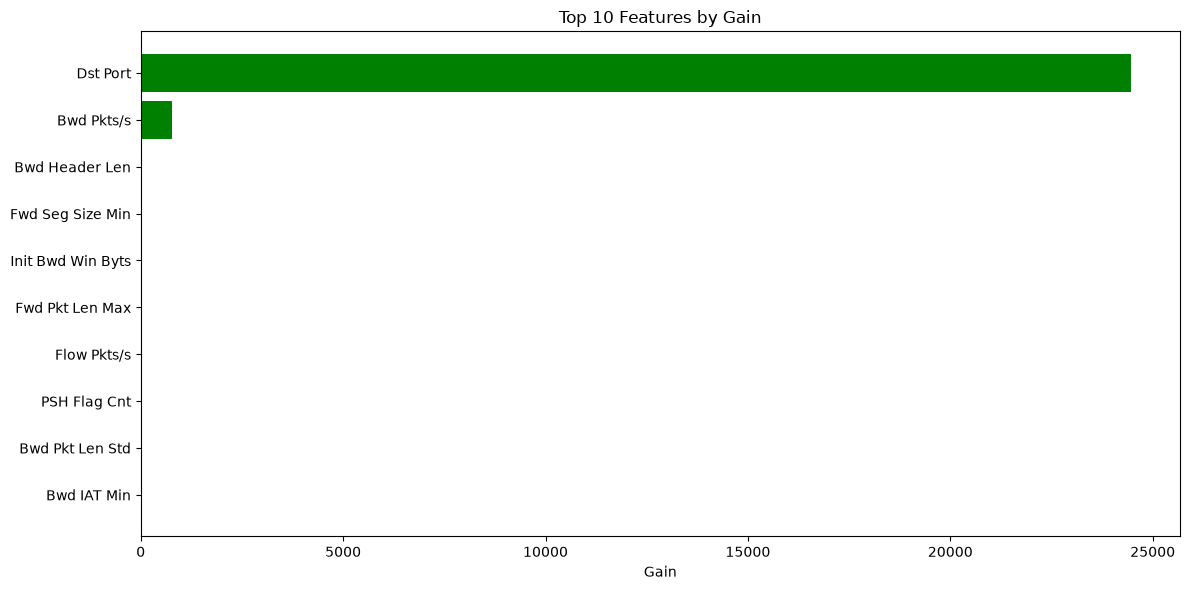

In [18]:
# Visualisasi
plt.figure(figsize=(12, 6))
top_10_df = importance_df.head(10).sort_values('Gain', ascending=True)
colors = ['green' if f in paper_features else 'steelblue' for f in top_10_df['Feature']]
plt.barh(top_10_df['Feature'], top_10_df['Gain'], color=colors)
plt.xlabel('Gain')
plt.title('Top 10 Features by Gain')
plt.tight_layout()
plt.show()

## 5. Feature Ablation Study (Table III dari paper)
Evaluasi F1-score, inference time, dan model size untuk berbagai jumlah fitur.

In [11]:
# Ablation study: Full, Top-30, Top-20, Top-10, Top-5
feature_sets = {
    'Full (all)': feature_names,
    'Top-30': importance_df.head(30)['Feature'].tolist(),
    'Top-20': importance_df.head(20)['Feature'].tolist(),
    'Top-10': importance_df.head(10)['Feature'].tolist(),
    'Top-5': importance_df.head(5)['Feature'].tolist(),
}

ablation_results = []
for name, feats in feature_sets.items():
    # Train
    model = XGBClassifier(
        max_depth=6, n_estimators=100, learning_rate=0.3,
        use_label_encoder=False, eval_metric='logloss', random_state=42
    )
    model.fit(X_train[feats], y_train)
    
    # Inference time (rata-rata 50 kali)
    times = []
    for _ in range(50):
        start = time.time()
        model.predict(X_test[feats])
        times.append((time.time() - start) * 1000)  # ms
    avg_time = np.mean(times)
    
    # F1-score
    y_pred = model.predict(X_test[feats])
    f1 = f1_score(y_test, y_pred) * 100
    
    # Model size
    temp_path = f'temp_model_{name.replace(" ", "")}.json'
    model.save_model(temp_path)
    size_kb = os.path.getsize(temp_path) / 1024
    os.remove(temp_path)
    
    ablation_results.append({
        'Feature Set': name,
        'Num Features': len(feats),
        'F1-Score (%)': f1,
        'Inference Time (ms)': avg_time,
        'Model Size (KB)': size_kb
    })

ablation_df = pd.DataFrame(ablation_results)
print("\n" + "="*70)
print("  TABLE III (Replikasi) - Feature Ablation Study")
print("="*70)
print(ablation_df.to_string(index=False))
print("="*70)
print("\nPaper results:")
print("  Full=99.70% | Top-30=99.82% | Top-20=99.84% | Top-10=99.85% | Top-5=96.40%")


  TABLE III (Replikasi) - Feature Ablation Study
Feature Set  Num Features  F1-Score (%)  Inference Time (ms)  Model Size (KB)
 Full (all)            78    100.000000            49.338174        78.443359
     Top-30            23    100.000000            29.420204        77.185547
     Top-20            20    100.000000            26.829548        78.050781
     Top-10            10     99.998667            26.872926        82.521484
      Top-5             5     99.998667            25.711265        91.343750

Paper results:
  Full=99.70% | Top-30=99.82% | Top-20=99.84% | Top-10=99.85% | Top-5=96.40%


## 6. 5-Fold Cross-Validation Benchmark (Table IV dari paper)
Membandingkan XGBoost, Random Forest, dan SVM menggunakan 10 fitur terbaik.

In [12]:
X_train_opt = X_train[top_10_features]
X_test_opt = X_test[top_10_features]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost CV
xgb_model = XGBClassifier(
    max_depth=6, n_estimators=100, learning_rate=0.3,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb_acc = cross_val_score(xgb_model, X_train_opt, y_train, cv=cv, scoring='accuracy')
xgb_prec = cross_val_score(xgb_model, X_train_opt, y_train, cv=cv, scoring='precision')
xgb_rec = cross_val_score(xgb_model, X_train_opt, y_train, cv=cv, scoring='recall')
xgb_f1 = cross_val_score(xgb_model, X_train_opt, y_train, cv=cv, scoring='f1')

# Random Forest CV
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_acc = cross_val_score(rf_model, X_train_opt, y_train, cv=cv, scoring='accuracy')
rf_prec = cross_val_score(rf_model, X_train_opt, y_train, cv=cv, scoring='precision')
rf_rec = cross_val_score(rf_model, X_train_opt, y_train, cv=cv, scoring='recall')
rf_f1 = cross_val_score(rf_model, X_train_opt, y_train, cv=cv, scoring='f1')

# SVM CV (scaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_opt)
svm_model = SVC(kernel='rbf', random_state=42)
svm_acc = cross_val_score(svm_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
svm_prec = cross_val_score(svm_model, X_train_scaled, y_train, cv=cv, scoring='precision')
svm_rec = cross_val_score(svm_model, X_train_scaled, y_train, cv=cv, scoring='recall')
svm_f1 = cross_val_score(svm_model, X_train_scaled, y_train, cv=cv, scoring='f1')

cv_results = pd.DataFrame({
    'Method': ['XGBoost', 'Random Forest', 'SVM (RBF)'],
    'Accuracy (%)': [f'{xgb_acc.mean()*100:.2f} +/- {xgb_acc.std()*100:.2f}',
                     f'{rf_acc.mean()*100:.2f} +/- {rf_acc.std()*100:.2f}',
                     f'{svm_acc.mean()*100:.2f} +/- {svm_acc.std()*100:.2f}'],
    'Precision (%)': [f'{xgb_prec.mean()*100:.2f} +/- {xgb_prec.std()*100:.2f}',
                      f'{rf_prec.mean()*100:.2f} +/- {rf_prec.std()*100:.2f}',
                      f'{svm_prec.mean()*100:.2f} +/- {svm_prec.std()*100:.2f}'],
    'Recall (%)': [f'{xgb_rec.mean()*100:.2f} +/- {xgb_rec.std()*100:.2f}',
                   f'{rf_rec.mean()*100:.2f} +/- {rf_rec.std()*100:.2f}',
                   f'{svm_rec.mean()*100:.2f} +/- {svm_rec.std()*100:.2f}'],
    'F1-Score (%)': [f'{xgb_f1.mean()*100:.2f} +/- {xgb_f1.std()*100:.2f}',
                     f'{rf_f1.mean()*100:.2f} +/- {rf_f1.std()*100:.2f}',
                     f'{svm_f1.mean()*100:.2f} +/- {svm_f1.std()*100:.2f}']
})

print("\n" + "="*80)
print("  TABLE IV (Replikasi) - Cross-Validation Performance (Mean +/- SD)")
print("="*80)
print(cv_results.to_string(index=False))
print("="*80)
print("\nPaper results:")
print("  XGBoost: 99.85 | RF: 99.70 | SVM: 94.14 (F1-Score %)")


  TABLE IV (Replikasi) - Cross-Validation Performance (Mean +/- SD)
       Method    Accuracy (%)   Precision (%)      Recall (%)    F1-Score (%)
      XGBoost 100.00 +/- 0.00  99.99 +/- 0.01 100.00 +/- 0.00 100.00 +/- 0.00
Random Forest 100.00 +/- 0.00 100.00 +/- 0.00 100.00 +/- 0.00 100.00 +/- 0.00
    SVM (RBF)  99.97 +/- 0.01  99.95 +/- 0.01 100.00 +/- 0.00  99.97 +/- 0.01

Paper results:
  XGBoost: 99.85 | RF: 99.70 | SVM: 94.14 (F1-Score %)


## 7. Final Hold-Out Test Evaluation + Confusion Matrix

In [13]:
# Train final models
xgb_final = XGBClassifier(
    max_depth=6, n_estimators=100, learning_rate=0.3,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb_final.fit(X_train_opt, y_train)
y_pred_xgb = xgb_final.predict(X_test_opt)

rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train_opt, y_train)
y_pred_rf = rf_final.predict(X_test_opt)

X_test_scaled = scaler.transform(X_test_opt)
svm_final = SVC(kernel='rbf', random_state=42)
svm_final.fit(X_train_scaled, y_train)
y_pred_svm = svm_final.predict(X_test_scaled)

# Results table
def eval_model(y_true, y_pred, name):
    return {
        'Algorithm': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    eval_model(y_test, y_pred_xgb, 'XGBoost'),
    eval_model(y_test, y_pred_rf, 'Random Forest'),
    eval_model(y_test, y_pred_svm, 'SVM (RBF)')
]).set_index('Algorithm')

print("\n" + "="*65)
print("  HOLD-OUT TEST RESULTS (10 Optimized Features)")
print("="*65)
print(results.to_string(float_format='{:.4f}'.format))
print("="*65)


  HOLD-OUT TEST RESULTS (10 Optimized Features)
               Accuracy  Precision  Recall  F1-Score
Algorithm                                           
XGBoost          1.0000     1.0000  1.0000    1.0000
Random Forest    1.0000     1.0000  1.0000    1.0000
SVM (RBF)        0.9998     0.9997  1.0000    0.9998



Confusion Matrix (XGBoost, 10 fitur):
  True Negatives  (Benign correct): 37518
  True Positives  (Attack correct): 37517
  False Positives (False alarm):    0
  False Negatives (Attack missed):  1

Paper reports: TN=37,845 | TP=37,830 | FP=30 | FN=45


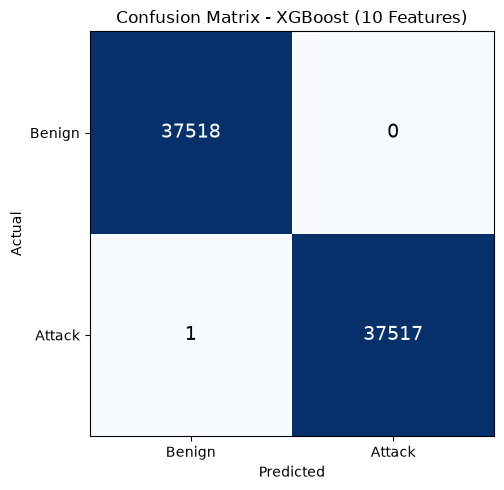

In [14]:
# Confusion Matrix - XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix (XGBoost, 10 fitur):")
print(f"  True Negatives  (Benign correct): {tn}")
print(f"  True Positives  (Attack correct): {tp}")
print(f"  False Positives (False alarm):    {fp}")
print(f"  False Negatives (Attack missed):  {fn}")
print(f"\nPaper reports: TN=37,845 | TP=37,830 | FP=30 | FN=45")

# Visual confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Benign', 'Attack'])
ax.set_yticklabels(['Benign', 'Attack'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - XGBoost (10 Features)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()

## 8. Efficiency Comparison (Table V dari paper)
Bandingkan model size dan inference time antar algoritma.

In [15]:
# XGBoost size & speed
xgb_final.save_model('xgboost_model.json')
xgb_size = os.path.getsize('xgboost_model.json') / 1024
times_xgb = []
for _ in range(50):
    start = time.time()
    xgb_final.predict(X_test_opt)
    times_xgb.append((time.time() - start) * 1000)
xgb_time = np.mean(times_xgb)

# Random Forest size & speed
joblib.dump(rf_final, 'rf_model.joblib')
rf_size = os.path.getsize('rf_model.joblib') / 1024
times_rf = []
for _ in range(50):
    start = time.time()
    rf_final.predict(X_test_opt)
    times_rf.append((time.time() - start) * 1000)
rf_time = np.mean(times_rf)

# SVM size & speed
joblib.dump(svm_final, 'svm_model.joblib')
svm_size = os.path.getsize('svm_model.joblib') / 1024
times_svm = []
for _ in range(50):
    start = time.time()
    svm_final.predict(X_test_scaled)
    times_svm.append((time.time() - start) * 1000)
svm_time = np.mean(times_svm)

# Cleanup temp files
os.remove('rf_model.joblib')
os.remove('svm_model.joblib')

efficiency_df = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest', 'SVM (RBF)'],
    'F1-Score (%)': [f1_score(y_test, y_pred_xgb)*100,
                     f1_score(y_test, y_pred_rf)*100,
                     f1_score(y_test, y_pred_svm)*100],
    'Model Size': [f'{xgb_size:.0f} KB', f'{rf_size/1024:.1f} MB', f'{svm_size/1024:.1f} MB'],
    'Inference Time (ms)': [f'{xgb_time:.1f}', f'{rf_time:.1f}', f'{svm_time:.1f}']
})

print("\n" + "="*65)
print("  TABLE V (Replikasi) - Efficiency Comparison (Top-10 Features)")
print("="*65)
print(efficiency_df.to_string(index=False))
print("="*65)
print("\nPaper results:")
print("  XGBoost: 145 KB, 18.4 ms | RF: 2.4 MB, 42.1 ms | SVM: 4.8 MB, 120.5 ms")


  TABLE V (Replikasi) - Efficiency Comparison (Top-10 Features)
        Model  F1-Score (%) Model Size Inference Time (ms)
      XGBoost     99.998667      83 KB                25.1
Random Forest    100.000000     0.3 MB               245.7
    SVM (RBF)     99.984010     0.0 MB              1802.3

Paper results:
  XGBoost: 145 KB, 18.4 ms | RF: 2.4 MB, 42.1 ms | SVM: 4.8 MB, 120.5 ms


## 9. Model Export (untuk AWS Lambda)

In [16]:
# Model sudah disimpan di step sebelumnya
print(f"Model XGBoost tersimpan: 'xgboost_model.json'")
print(f"Size: {os.path.getsize('xgboost_model.json')/1024:.1f} KB")
print(f"\nFitur yang digunakan ({len(top_10_features)} fitur):")
for i, feat in enumerate(top_10_features, 1):
    print(f"  {i}. {feat}")

# Verifikasi
xgb_loaded = XGBClassifier()
xgb_loaded.load_model('xgboost_model.json')
y_verify = xgb_loaded.predict(X_test_opt)
assert np.array_equal(y_pred_xgb, y_verify)
print(f"\nVerifikasi OK: model JSON konsisten.")

Model XGBoost tersimpan: 'xgboost_model.json'
Size: 82.5 KB

Fitur yang digunakan (10 fitur):
  1. Dst Port
  2. Bwd Pkts/s
  3. Bwd Header Len
  4. Fwd Seg Size Min
  5. Init Bwd Win Byts
  6. Fwd Pkt Len Max
  7. Flow Pkts/s
  8. PSH Flag Cnt
  9. Bwd Pkt Len Std
  10. Bwd IAT Min

Verifikasi OK: model JSON konsisten.


## 10. Ringkasan & Bahan Diskusi

### Perbedaan dengan Paper:
- Dataset kita (raw): 625,919 samples (imbalanced) vs Paper: 380,000 (balanced)
- Versi XGBoost: 3.2.0 vs Paper: 1.7.5
- Python: 3.14 vs Paper: 3.9

### Poin Diskusi:
1. Apakah top-10 fitur kita sama dengan paper? Kenapa bisa berbeda?
2. Apakah F1-score kita mendekati 99.85%?
3. Apakah SVM konsisten underperform dibanding tree-based methods?
4. Pengaruh dataset version/balancing terhadap feature importance ranking